# MS Lesion Segmentation (MSLesSeg) — Runner

Notebook unico che funziona **in locale da VS Code** e **su Colab**. Rileva l'ambiente,
si posiziona nella root del repo, carica la config e ispeziona/visualizza il dataset.
Il codice vero sta in `src/` (versionato): il notebook è solo il "driver".


## 1. Ambiente + root del repo
Rileva Colab vs locale, trova la cartella del repo e la imposta come working dir.

In [3]:
import os, sys

def find_repo_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    for _ in range(8):
        if os.path.exists(os.path.join(d, "configs", "base.yaml")):
            return d
        p = os.path.dirname(d)
        if p == d:
            break
        d = p
    raise FileNotFoundError("Root del repo non trovata: apri la cartella 'ms-lesion-seg' in VS Code.")

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    # Se il repo è su GitHub, decommenta e adatta:
    # !git clone https://github.com/<TUO_UTENTE>/ms-lesion-seg.git /content/ms-lesion-seg
    # os.chdir("/content/ms-lesion-seg")

REPO = find_repo_root()
os.chdir(REPO)
if REPO not in sys.path:
    sys.path.insert(0, REPO)
print("Ambiente:", "Colab" if IN_COLAB else "Locale (VS Code)")
print("Repo root:", REPO)

Ambiente: Locale (VS Code)
Repo root: c:\Users\massi\Documents\GitHub\ms-lesion-seg


## 2. Dipendenze
In locale eseguile **una volta** nel tuo ambiente conda/venv, poi ricommenta la riga.

In [4]:
# %pip install "monai>=1.3" nibabel SimpleITK omegaconf scikit-image matplotlib pandas
# Nota: su Colab torch c'è già. In locale con GPU installa il build CUDA da pytorch.org.
import importlib.util
for m in ["omegaconf", "nibabel", "numpy", "pandas", "matplotlib"]:
    print(f"  {m}:", "OK" if importlib.util.find_spec(m) else "MANCANTE (installa)")

  omegaconf: OK
  nibabel: OK
  numpy: OK
  pandas: OK
  matplotlib: OK


## 3. Carica config + indicizza il dataset (Fase 1)
Usa i path in `configs/base.yaml`. Verifica che gli esempi di filename combacino col pattern.

In [5]:
from src.config import load_config
from src.data.indexing import discover_cases, attach_metadata, make_patient_splits
from collections import Counter

cfg = load_config("configs/base.yaml")
root = os.path.join(cfg.paths.data_root, "train")
cases = discover_cases(root, cfg.data.filename_pattern, cfg.data.modality_aliases)
cases = attach_metadata(cases, cfg.paths.metadata_csv)

n_pat = len({c["patient"] for c in cases})
print(f"Casi (train): {len(cases)} | pazienti: {n_pat}")
train, val = make_patient_splits(cases, val_fraction=0.2, seed=cfg.project.seed)
print(f"Split per paziente -> train: {len(train)} casi | val: {len(val)} casi (no leakage)")
print("\nSottogruppi:")
for k in ("sex", "age_band", "field_strength"):
    print(f"  {k}: {dict(Counter(str(c.get(k, 'NA')) for c in cases))}")

Casi (train): 93 | pazienti: 53
Split per paziente -> train: 77 casi | val: 16 casi (no leakage)

Sottogruppi:
  sex: {'F': 54, 'M': 39}
  age_band: {'18-29': 30, '30-44': 44, '45+': 19}
  field_strength: {'NA': 93}


## 4. Visualizzazione (EDA)
Slice assiale con più lesione: FLAIR, maschera e overlay. Feedback visivo immediato in VS Code.

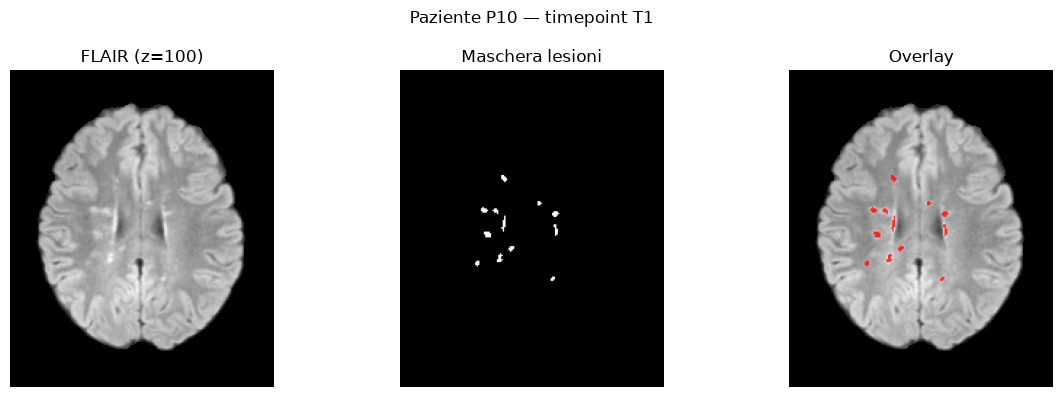

In [6]:
import numpy as np, nibabel as nib
import matplotlib.pyplot as plt

case = next(c for c in cases if c["mask"])
flair = np.asarray(nib.load(case["images"]["FLAIR"]).dataobj)
mask = np.asarray(nib.load(case["mask"]).dataobj)
z = int(np.argmax(mask.sum(axis=(0, 1))))  # slice con area lesionale massima

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(np.rot90(flair[:, :, z]), cmap="gray"); ax[0].set_title(f"FLAIR (z={z})")
ax[1].imshow(np.rot90(mask[:, :, z]), cmap="gray");  ax[1].set_title("Maschera lesioni")
ax[2].imshow(np.rot90(flair[:, :, z]), cmap="gray")
overlay = np.ma.masked_where(mask[:, :, z] == 0, mask[:, :, z])
ax[2].imshow(np.rot90(overlay), cmap="autumn", alpha=0.8); ax[2].set_title("Overlay")
for a in ax:
    a.axis("off")
plt.suptitle(f"Paziente {case['patient']} — timepoint {case['timepoint']}")
plt.tight_layout(); plt.show()

## 5. Preprocessing (Fase 2)
Normalizza le intensità per modalità, ritaglia al cervello, porta le slice a
`data.spatial_size` e salva `.npy` + `meta.json` in `paths.processed_root`.

**Da eseguire una volta sola** (~10-20 min, ~3-4 GB su disco). Prova prima con `--limit 3`.
I run successivi saltano i casi già presenti (usa `--force` per rifarli).

In [ ]:
# Prova rapida su 3 casi (consigliata la prima volta):
# !python scripts/01_preprocess.py --split train --limit 3

# Dataset completo (train + test) — decommenta quando la prova è andata bene:
#!python scripts/01_preprocess.py --split train
#!python scripts/01_preprocess.py --split test

[*] Sorgente : C:/Users/massi/Desktop/MSLesSeg Dataset\test
[*] Output   : C:/Users/massi/Desktop/MSLesSeg_Processed\test
[*] Casi     : 22 | modalità: ['FLAIR', 'T1', 'T2'] | slice [192, 192]

  [1/22] P54_T1: 159 slice (40 con lesione) | lesione tot=1332 voxel
  [2/22] P55_T1: 157 slice (80 con lesione) | lesione tot=5209 voxel
  [3/22] P56_T1: 165 slice (29 con lesione) | lesione tot=1754 voxel
  [4/22] P57_T1: 159 slice (126 con lesione) | lesione tot=42098 voxel
  [5/22] P58_T1: 163 slice (97 con lesione) | lesione tot=6689 voxel
  [6/22] P59_T1: 175 slice (56 con lesione) | lesione tot=2403 voxel
  [7/22] P60_T1: 156 slice (111 con lesione) | lesione tot=6649 voxel
  [8/22] P61_T1: 177 slice (72 con lesione) | lesione tot=4738 voxel
  [9/22] P62_T1: 153 slice (91 con lesione) | lesione tot=4182 voxel
  [10/22] P63_T1: 169 slice (68 con lesione) | lesione tot=2908 voxel
  [11/22] P64_T1: 166 slice (82 con lesione) | lesione tot=4760 voxel
  [12/22] P65_T1: 157 slice (114 con lesio

## 6. Dataset 2.5D + DataLoader
Costruisce gli split, il dataset di slice e il sampler bilanciato.

In [8]:
from src.data.preprocessing import load_index
from src.data.dataset import build_dataloaders
from src.data.indexing import make_patient_splits

cfg = load_config("configs/base.yaml")
proc_cases = load_index(cfg.paths.processed_root, "train")
tr_cases, va_cases = make_patient_splits(proc_cases, 0.2, cfg.project.seed)

train_loader, val_loader, train_ds, val_ds = build_dataloaders(cfg, tr_cases, va_cases)
print(f"Casi preprocessati: {len(proc_cases)} -> train {len(tr_cases)} / val {len(va_cases)}")
print(f"Slice: train {len(train_ds)} | val {len(val_ds)}")
print(f"Slice con lesione (naturale): {train_ds.is_positive.mean()*100:.1f}% "
      f"-> sovracampionate al {cfg.data.pos_neg_ratio*100:.0f}%")

batch = next(iter(train_loader))
print(f"\nBatch -> image {tuple(batch['image'].shape)} | label {tuple(batch['label'].shape)}")
print(f"Canali attesi: {cfg.model.in_channels} "
      f"({len(cfg.data.modalities)} modalità x {2*cfg.data.context_slices+1} slice)")

Casi preprocessati: 93 -> train 77 / val 16
Slice: train 12022 | val 2525
Slice con lesione (naturale): 47.5% -> sovracampionate al 50%

Batch -> image (16, 9, 192, 192) | label (16, 1, 192, 192)
Canali attesi: 9 (3 modalità x 3 slice)


c:\Users\massi\miniconda3\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


## 7. Sanity check visivo del batch
Controllo che immagine e maschera restino allineate dopo le augmentation.

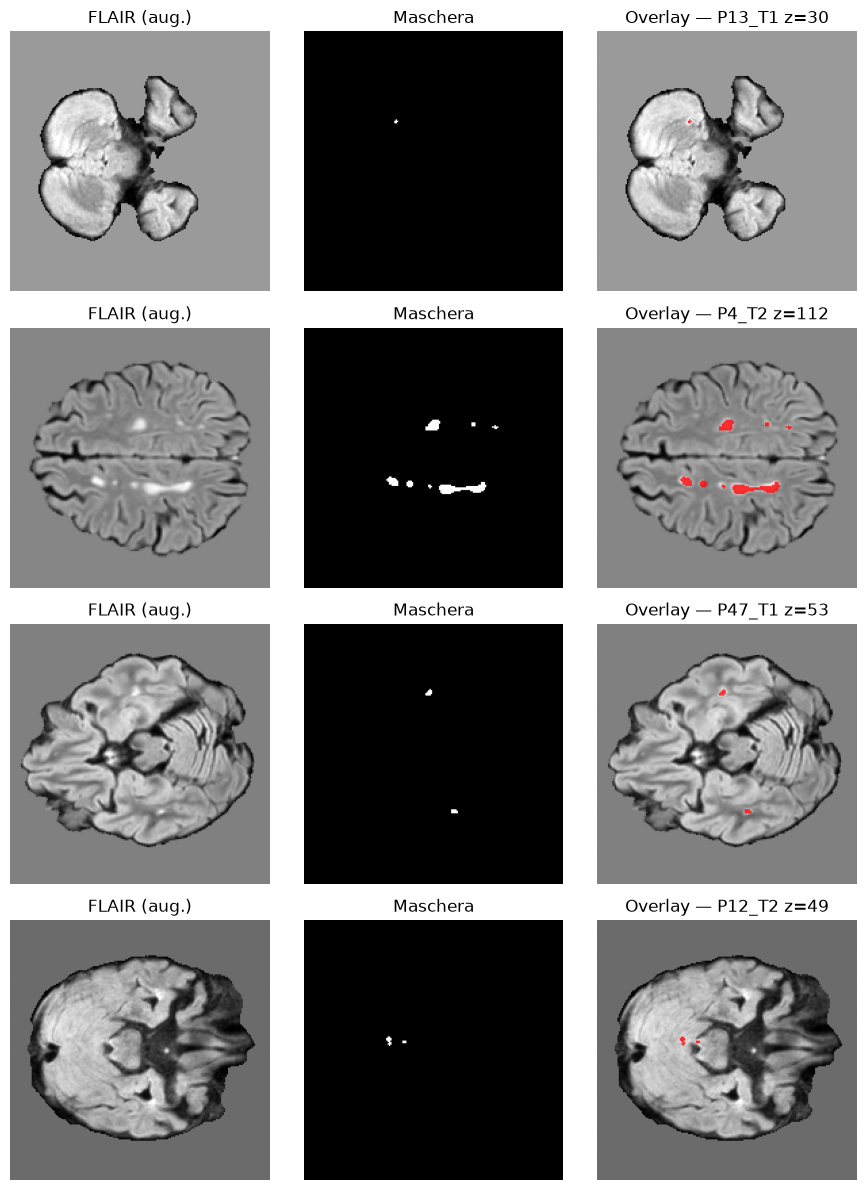

In [9]:
import matplotlib.pyplot as plt
import numpy as np

ctr = cfg.data.context_slices  # indice del canale centrale (slice della GT)
pos = [i for i in range(len(batch["label"])) if batch["label"][i].sum() > 0][:4]
if not pos:
    print("Nessuna slice con lesione in questo batch: rilancia la cella.")
else:
    fig, axes = plt.subplots(len(pos), 3, figsize=(9, 3*len(pos)), squeeze=False)
    for r, i in enumerate(pos):
        img = batch["image"][i, ctr].numpy()          # FLAIR, slice centrale
        lab = batch["label"][i, 0].numpy()
        axes[r][0].imshow(img, cmap="gray"); axes[r][0].set_title("FLAIR (aug.)")
        axes[r][1].imshow(lab, cmap="gray"); axes[r][1].set_title("Maschera")
        axes[r][2].imshow(img, cmap="gray")
        axes[r][2].imshow(np.ma.masked_where(lab == 0, lab), cmap="autumn", alpha=0.8)
        axes[r][2].set_title(f"Overlay — {batch['case'][i]} z={int(batch['z'][i])}")
        for a in axes[r]: a.axis("off")
    plt.tight_layout(); plt.show()

## Prossime fasi
- **Fase 3** — modelli: U-Net baseline, Attention U-Net + deep supervision
- **Fase 4** — loss (Dice/Focal/Tversky), metriche (Dice/IoU/HD95/lesion-wise), training loop
- **Fase 5** — esperimenti core; **Fase 6** — robustezza 1.5T/3T; **Fase 7** — fairness + XAI